### **MetaBox — End-to-End Test & Example Notebook**

This notebook is a **comprehensive walkthrough and test harness** for every
public submodule of the `metabox` package.

It is organised bottom-up so each section only depends on what came before it:

| §  | Module             | What it covers                                                          |
|----|--------------------|-------------------------------------------------------------------------|
| 0  | Environment        | Python / TF / metabox import sanity checks                              |
| 1  | `utils`            | `Feature`, `Incidence`, wavelength→RGB, incidence unraveling            |
| 2  | `raster`           | `Canvas` + `Circle` / `Rectangle` / `Polygon` rasterisation             |
| 3  | `rcwa.Material`    | Loading optical constants from CSV                                      |
| 4  | `rcwa` — UnitCell  | Building parameterised unit cells, ProtoUnitCell, eps maps              |
| 5  | `rcwa_tf` — solver | Low-level RCWA (`convmat`, `redheffer_star_product`, `simulate_rcwa`)   |
| 6  | `rcwa.simulate*`   | Single & batched parameter sweeps via `simulate_parameterized_unit_cells` |
| 7  | `expansion`        | 1D → 2D radial expansion + basis caching                                |
| 8  | `propagation`      | `Field1D`/`Field2D`, transfer functions, free-space propagation         |
| 9  | `metrics`          | Strehl-ratio / MTF volume / max & center intensity                      |
| 10 | `modeling`         | Sampling a protocell + training a neural surrogate (small, fast run)    |
| 11 | `assembly`         | `Aperture`, `Metasurface`, `LensAssembly`, FOM evaluation               |
| 12 | Optimisation       | Gradient-based metalens optimisation with TF Adam                       |
| 13 | `export`           | GDSII export of the optimised metalens                                  |
| 14 | Summary            | Final metrics, what was tested, troubleshooting tips                    |

> **Runtime:** sections 1–9 run in seconds. Sections 10–13 (training +
> optimisation + GDS write) take a few minutes on CPU. Each heavy section is
> gated by a `RUN_HEAVY` flag near the top so you can skip them on a cold run.

> **Layout assumption:** this notebook lives at the project root, alongside
> the `metabox/` directory. Adjust `METABOX_PATH` in §0 if not.


### **0. Environment & imports**

We pin TensorFlow's log level, suppress noisy deprecation warnings, and check
that `metabox` imports cleanly. If any of these fail, fix them before going
further — every later section depends on a working metabox import.

In [1]:
import os, sys, warnings, time, pathlib
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sys.path.insert(0, os.path.abspath(".."))


In [2]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

tf.random.set_seed(0)
np.random.seed(0)

print(f"Python    : {sys.version.split()[0]}")
print(f"NumPy     : {np.__version__}")
print(f"TensorFlow: {tf.__version__}")
print(f"GPUs seen : {tf.config.list_physical_devices('GPU') or 'CPU only'}")

import metabox3
from metabox3 import utils, raster, rcwa, rcwa_tf, propagation, expansion, metrics, modeling, assembly

RUN_HEAVY = True
print(f"RUN_HEAVY : {RUN_HEAVY}")

Python    : 3.11.9
NumPy     : 2.4.2
TensorFlow: 2.20.0
GPUs seen : CPU only
RUN_HEAVY : True


### **1. `metabox.utils` — primitive types**

`utils` defines the two data classes that flow through the entire pipeline:

- **`Feature`** — a named, bounded scalar that can later be promoted to a
  `tf.Variable` for optimisation.
- **`Incidence`** — wavelength(s) + AOI angles + Jones polarisation vector.

We also test `unravel_incidence` (which flattens an `Incidence` into the
batch tensors RCWA expects) and `wavelength_to_rgb` (used by the field
visualiser).

In [3]:
# 1a. Feature — bounded scalar parameter
diam = utils.Feature(vmin=80e-9, vmax=300e-9, name="diameter", sampling=20)
diam.initialize_value()
assert 80e-9 <= float(diam.value[0]) <= 300e-9
diam.set_variable()
assert isinstance(diam.value, tf.Variable)
print(f"diameter feature: vmin={diam.vmin*1e9:.0f} nm, vmax={diam.vmax*1e9:.0f} nm, "
      f"value={float(diam.value[0])*1e9:.1f} nm, sampling={diam.sampling}")

# 1b. Equality and hashing — features compare by NAME (used to dedup across nested dataclasses)
diam2 = utils.Feature(vmin=0, vmax=1, name="diameter")
assert diam == diam2 and hash(diam) == hash(diam2)
print("Feature equality by name: OK")

# 1c. Incidence + unravel
inc = utils.Incidence(
    wavelength=(532e-9, 633e-9),    # 2 wavelengths
    theta=(0.0, 5.0),               # 2 polar angles  →  2 × 2 × 1 = 4 rows per λ → 8 rows total
    phi=(0.0,),
    jones_vector=(1, 0),            # x-polarised
)
unr = utils.unravel_incidence(inc)
print("Unravelled keys:", list(unr.keys()))
print("Batch length    :", unr['wavelength'].shape[0],
      "(expected 2λ × 2θ × 1φ = 4)... wait, that's 4")
# Actually len = nλ * nθ * nφ = 2*2*1 = 4
assert unr['wavelength'].shape[0] == 4
print(f"theta (rad): {unr['theta'].numpy()}")
print(f"pte (y-pol): {unr['pte'].numpy()}")
print(f"ptm (x-pol): {unr['ptm'].numpy()}")

diameter feature: vmin=80 nm, vmax=300 nm, value=144.2 nm, sampling=20
Feature equality by name: OK
Unravelled keys: ['wavelength', 'theta', 'phi', 'ptm', 'pte']
Batch length    : 4 (expected 2λ × 2θ × 1φ = 4)... wait, that's 4
theta (rad): [0.         0.08726646 0.         0.08726646]
pte (y-pol): [0.+0.j 0.+0.j 0.+0.j 0.+0.j]
ptm (x-pol): [1.+0.j 1.+0.j 1.+0.j 1.+0.j]


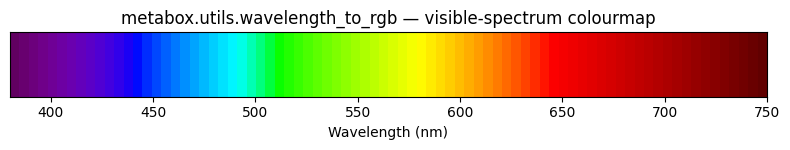

In [4]:
# 1d. wavelength → RGB
wls_nm = np.linspace(380, 750, 80)
rgbs = np.array([utils.wavelength_to_rgb(w * 1e-9) for w in wls_nm])

fig, ax = plt.subplots(figsize=(8, 1.6))
ax.imshow(rgbs[np.newaxis, :, :], aspect="auto",
          extent=[wls_nm.min(), wls_nm.max(), 0, 1])
ax.set_yticks([])
ax.set_xlabel("Wavelength (nm)")
ax.set_title("metabox.utils.wavelength_to_rgb — visible-spectrum colourmap")
plt.tight_layout(); plt.show()

### **2. `metabox.raster` — shape rasterisation**

`raster.Canvas` is the differentiable rasteriser used to build the
permittivity image of every unit-cell layer. We test the three primitive
shapes and the 4-fold-symmetry option.

> The canvas operates in **dimensionless units** at this layer (it just needs
> consistent `x_width` / `y_width` / `spacing`). When called from
> `rcwa.UnitCell`, those are populated with real metres.

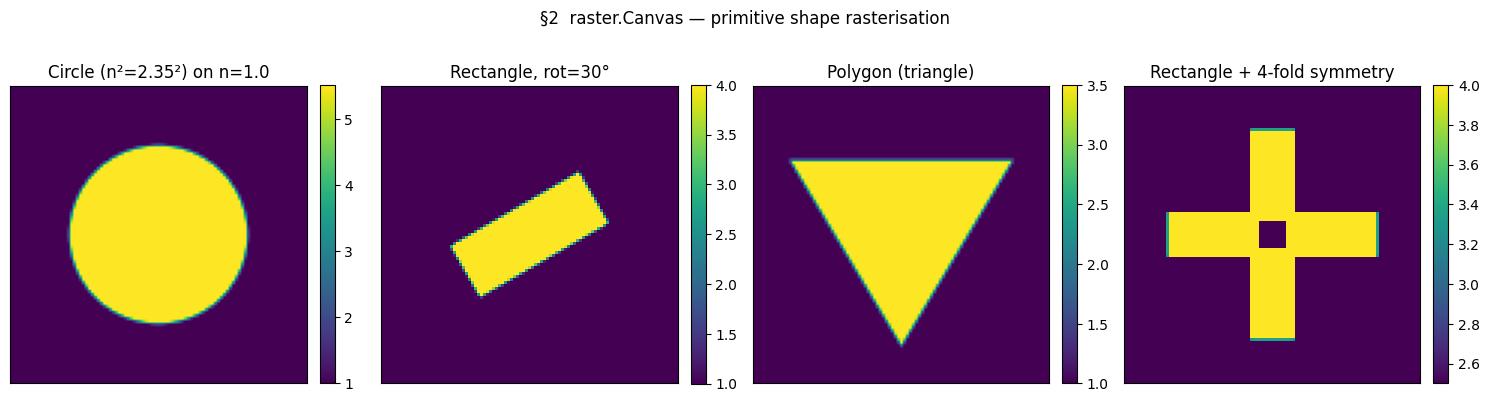

In [5]:
def show_canvas(arr, title, ax):
    arr = np.asarray(arr)
    if np.iscomplexobj(arr):
        arr = np.real(arr)
    im = ax.imshow(arr, origin="lower", cmap="viridis")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# 2a. Circle
c1 = raster.Canvas(x_width=400e-9, y_width=400e-9, spacing=4e-9, background_value=1.0)
shapes = [raster.Circle(value=2.35**2, center=(0, 0), radius=120e-9)]
show_canvas(c1.rasterize(shapes), "Circle (n²=2.35²) on n=1.0", axes[0])

# 2b. Rectangle (rotated)
c2 = raster.Canvas(x_width=400e-9, y_width=400e-9, spacing=4e-9, background_value=1.0)
shapes = [raster.Rectangle(value=4.0, center=(0, 0),
                           x_width=200e-9, y_width=80e-9, rotation_deg=30)]
show_canvas(c2.rasterize(shapes), "Rectangle, rot=30°", axes[1])

# 2c. Polygon (triangle)
c3 = raster.Canvas(x_width=400e-9, y_width=400e-9, spacing=4e-9, background_value=1.0)
tri = raster.Polygon(value=3.5,
                     vertices=[(-150e-9, -100e-9), (150e-9, -100e-9), (0, 150e-9)])
show_canvas(c3.rasterize([tri]), "Polygon (triangle)", axes[2])

# 2d. 4-fold symmetry enforced
c4 = raster.Canvas(x_width=400e-9, y_width=400e-9, spacing=4e-9,
                   background_value=1.0, enforce_4fold_symmetry=True)
asym = raster.Rectangle(value=4.0, center=(80e-9, 0),
                        x_width=120e-9, y_width=60e-9, rotation_deg=0)
show_canvas(c4.rasterize([asym]), "Rectangle + 4-fold symmetry", axes[3])

plt.suptitle("§2  raster.Canvas — primitive shape rasterisation", y=1.02)
plt.tight_layout(); plt.show()

### **3. `metabox.rcwa.Material` — dispersive optical constants**

`Material` reads `n(λ)` and `k(λ)` from a CSV in `metabox/material_data/` and
exposes `index_at(wavelength)` for any λ within range. The bundled
`sample.csv` covers 0.4 – 0.7 µm — perfect for visible-light examples.

If you have additional CSVs (e.g. `TiO2.csv`, `Si.csv`, `SiO2.csv` from
refractiveindex.info), drop them in `metabox/material_data/` and they will
appear in `get_avaliable_materials()`.

Available materials: ['GaN', 'MoO3', 'N-BK7', 'Nb2O5', 'quartz', 'sample', 'Si3N4', 'Si_ir', 'Si_visible', 'TiO2', 'ZnO', 'ZrO2']
sample: λ range = 0.35 – 10.00 µm
Index @ 532 nm = 2.424+0.000j
Index @ 633 nm = 2.385+0.000j


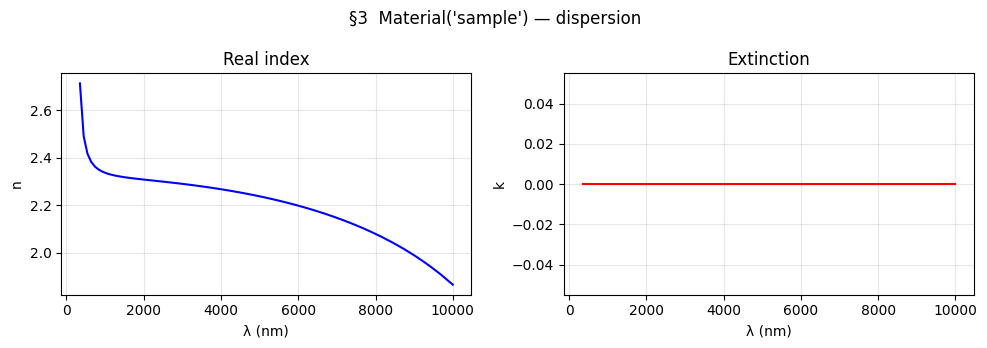

In [6]:
# 3a. List bundled materials
print("Available materials:", rcwa.get_avaliable_materials())

# 3b. Load the bundled 'sample' material
mat = rcwa.Material(name="GaN")
print(f"sample: λ range = {mat.min_wl_n*1e6:.2f} – {mat.max_wl_n*1e6:.2f} µm")
print(f"Index @ 532 nm = {mat.index_at(532e-9):.3f}")
print(f"Index @ 633 nm = {mat.index_at(633e-9):.3f}")

# 3c. Plot dispersion
wls = np.linspace(mat.min_wl_n, mat.max_wl_n, 100)
n_vals = np.array([np.real(mat.index_at(w)) for w in wls])
k_vals = np.array([np.imag(mat.index_at(w)) for w in wls])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(wls*1e9, n_vals, "b-"); axes[0].set_xlabel("λ (nm)"); axes[0].set_ylabel("n"); axes[0].set_title("Real index")
axes[1].plot(wls*1e9, k_vals, "r-"); axes[1].set_xlabel("λ (nm)"); axes[1].set_ylabel("k"); axes[1].set_title("Extinction")
for a in axes: a.grid(alpha=0.3)
plt.suptitle(f"§3  Material('sample') — dispersion"); plt.tight_layout(); plt.show()

### **4. `metabox.rcwa` — building unit cells**

A metasurface unit cell is a stack of `Layer`s, each of which is a homogeneous
background with embedded `Shape`s. When any geometry parameter is a `Feature`,
the cell becomes a **`ProtoUnitCell`** — a parameterised template that can
generate concrete `UnitCell` instances from a parameter tensor.

This is the foundation for everything sweep-/optimisation-related.

Fixed unit cell features: []
→ no Features means it's a concrete cell, not a proto.
ε stack shape: (1, 64, 64) (n_layers, Nx, Ny)


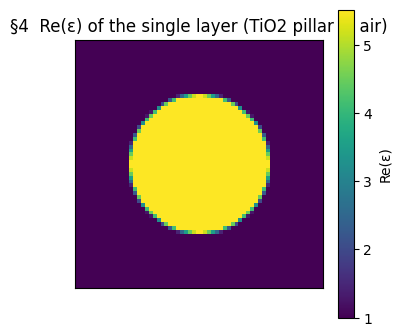

In [7]:
# 4a. Plain UnitCell — fixed-geometry pillar on glass, period 350 nm, height 600 nm
period = 350e-9
height = 600e-9

pillar = rcwa.Circle(material=2.35, radius=100e-9)              # n=2.35 (TiO2 @ ~532 nm)
layer_pillar = rcwa.Layer(material=1.0, thickness=height, shapes=(pillar,))
uc_fixed = rcwa.UnitCell(
    layers=[layer_pillar],
    periodicity=(period, period),
    refl_index=1.0,         # air above
    tran_index=1.46,        # glass below
)
uc_fixed.initialize_values()
print("Fixed unit cell features:", uc_fixed.get_cell_unique_features())  # → []
print("→ no Features means it's a concrete cell, not a proto.")

# Materialise the permittivity at λ=532 nm and a 64×64 spatial grid
eps_stack = uc_fixed.get_epsilon(x_resolution=64, wavelength=532e-9)
print("ε stack shape:", eps_stack.shape, "(n_layers, Nx, Ny)")

plt.figure(figsize=(4, 4))
plt.imshow(np.real(eps_stack[0]), origin="lower", cmap="viridis")
plt.colorbar(label="Re(ε)")
plt.title("§4  Re(ε) of the single layer (TiO2 pillar in air)")
plt.xticks([]); plt.yticks([]); plt.show()

Proto features: ['diameter']
Proto period  : 3.5e-07 m
Generated 5 concrete UnitCells


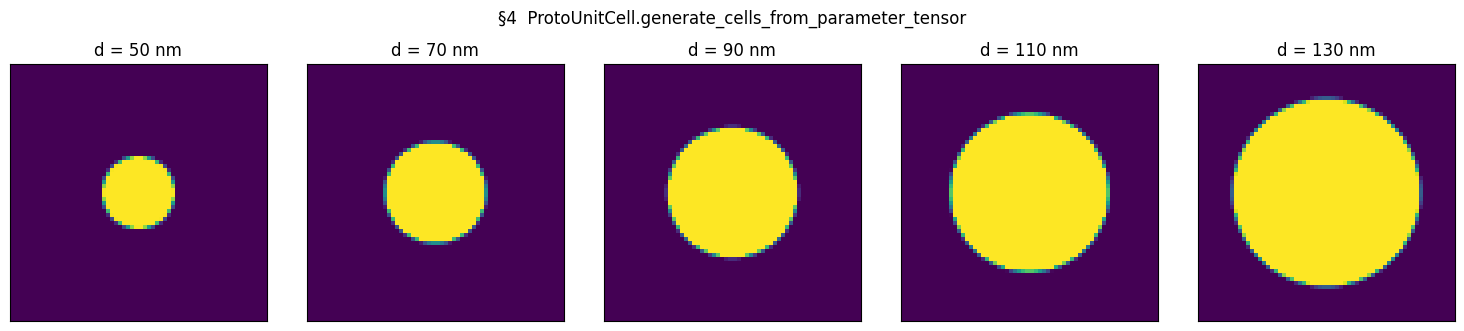

In [8]:
# 4b. ProtoUnitCell — same layout but the radius is a Feature
diam_feature = utils.Feature(vmin=40e-9, vmax=150e-9, name="diameter", sampling=10)
pillar_p = rcwa.Circle(material=2.35, radius=diam_feature)
layer_p = rcwa.Layer(material=1.0, thickness=height, shapes=(pillar_p,))
uc_proto = rcwa.UnitCell(
    layers=[layer_p],
    periodicity=(period, period),
    refl_index=1.0,
    tran_index=1.46,
)
proto = rcwa.ProtoUnitCell(uc_proto)

print("Proto features:", [f.name for f in proto.features])
print("Proto period  :", proto.period, "m")

# Generate 5 concrete unit cells with diameters from 50 to 130 nm
diameters = np.linspace(50e-9, 130e-9, 5).reshape(1, -1)   # shape (n_features=1, N=5)
diameters_tf = tf.constant(diameters, dtype=tf.float32)
cells_5 = proto.generate_cells_from_parameter_tensor(diameters_tf)
print(f"Generated {len(cells_5)} concrete UnitCells")

# Visualise their permittivity at 532 nm
fig, axes = plt.subplots(1, 5, figsize=(15, 3.2))
for ax, cell, d in zip(axes, cells_5, diameters[0]):
    eps = cell.get_epsilon(x_resolution=64, wavelength=532e-9)
    ax.imshow(np.real(eps[0]), origin="lower", cmap="viridis")
    ax.set_title(f"d = {d*1e9:.0f} nm"); ax.set_xticks([]); ax.set_yticks([])
plt.suptitle("§4  ProtoUnitCell.generate_cells_from_parameter_tensor", y=1.02)
plt.tight_layout(); plt.show()

### **5. `metabox.rcwa_tf` — low-level RCWA primitives**

These are the building blocks `rcwa.simulate_one` calls under the hood:

- **`convmat`** — Fourier-domain convolution matrix of the rasterised ε map.
- **`redheffer_star_product`** — combines two scattering matrices.
- **`expand_and_tile_tf`** — utility to broadcast a small tensor over batch
  / pixels / pixels.
- **`eig_general`** — custom-gradient eigendecomposition (we just smoke-test
  shapes here; the gradient is exercised implicitly by §12).

We don't normally call these directly, but verifying them in isolation makes
debugging much easier when the high-level pipeline misbehaves.

convmat output shape: (25, 25) (expected: (25, 25) )


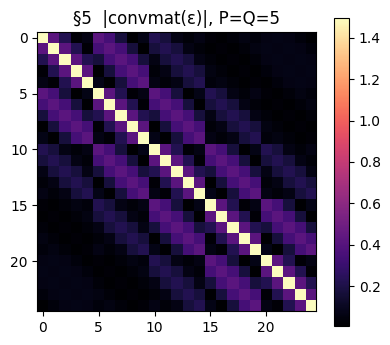

In [9]:
# 5a. convmat on a simple 2D ε image (the "easy" 2D-input branch)
Nx, Ny = 32, 32
eps_img = np.ones((Nx, Ny), dtype=np.complex64)
# embed a small high-index disc
yy, xx = np.ogrid[:Nx, :Ny]
mask = (xx - Nx//2)**2 + (yy - Ny//2)**2 <= 6**2
eps_img[mask] = 5.5
eps_tf = tf.constant(eps_img)

P, Q = 5, 5  # spatial harmonics
C = rcwa_tf.convmat(eps_tf, P, Q)
print("convmat output shape:", C.shape, "(expected:", (P*Q, P*Q), ")")
assert tuple(C.shape) == (P*Q, P*Q)

# Quick visualisation of |C|
plt.figure(figsize=(4.5, 4))
plt.imshow(np.abs(C.numpy()), cmap="magma")
plt.title(f"§5  |convmat(ε)|, P=Q={P}"); plt.colorbar(); plt.show()

In [10]:
# 5b. redheffer_star_product on two trivial S-matrices
batch, px, py, dim = 1, 1, 1, 4
def trivial_S(diag_val):
    I = tf.eye(dim, dtype=tf.complex64)
    Z = tf.zeros_like(I)
    return {
        "S11": diag_val * Z[None, None, None],
        "S12": I[None, None, None],
        "S21": I[None, None, None],
        "S22": diag_val * Z[None, None, None],
    }
SA = trivial_S(0.0)
SB = trivial_S(0.0)
S = rcwa_tf.redheffer_star_product(SA, SB)
# When both halves are pure transmitters, the combined T should still be I
assert np.allclose(S['S12'].numpy()[0, 0, 0], np.eye(dim))
print("redheffer_star_product on two pass-throughs → identity transmission ✓")

# 5c. expand_and_tile_tf
small = tf.eye(3, dtype=tf.complex64)
big = rcwa_tf.expand_and_tile_tf(small, batchSize=2, pixelsX=4, pixelsY=4)
assert tuple(big.shape) == (2, 4, 4, 3, 3)
print(f"expand_and_tile_tf: {small.shape} → {big.shape} ✓")

redheffer_star_product on two pass-throughs → identity transmission ✓
expand_and_tile_tf: (3, 3) → (2, 4, 4, 3, 3) ✓


### **6. End-to-end RCWA sweep — phase vs diameter**

Now we put it together: sweep pillar diameter, run RCWA at each value, and
plot the **complex transmission** (amplitude + phase) of the zeroth diffraction
order.

This is the canonical curve every metalens designer needs — a phase-vs-diameter
look-up table that becomes the metasurface design library.

In [11]:
# Build a sweep proto-cell: diameter ∈ [50, 160] nm
diam_feat = utils.Feature(vmin=50e-9, vmax=160e-9, name="diameter", sampling=20)
sweep_pillar = rcwa.Circle(material=2.35, radius=diam_feat)
sweep_layer  = rcwa.Layer(material=1.0, thickness=600e-9, shapes=(sweep_pillar,))
sweep_uc     = rcwa.UnitCell(layers=[sweep_layer],
                             periodicity=(350e-9, 350e-9),
                             refl_index=1.0, tran_index=1.46)
sweep_proto  = rcwa.ProtoUnitCell(sweep_uc)

incidence = utils.Incidence(wavelength=(532e-9,))    # single-λ for speed
sim_cfg   = rcwa.SimConfig(
    xy_harmonics=(3, 3),     # 3×3 harmonics — small but enough for circular pillars
    resolution=64,
    minibatch_size=20,
    return_tensor=True,
    return_zeroth_order=True,
    use_transmission=True,
    include_z_comp=False,
)

N = 20
diameters_sweep = np.linspace(50e-9, 160e-9, N, dtype=np.float32).reshape(1, -1)
print(f"Running RCWA over {N} diameters at λ=532 nm ...")
t0 = time.perf_counter()
out = rcwa.simulate_parameterized_unit_cells(
    parameter_tensor=tf.constant(diameters_sweep),
    proto_cell=sweep_proto,
    incidence=incidence,
    sim_config=sim_cfg,
)
print(f"  done in {time.perf_counter()-t0:.1f} s, output shape = {out.shape}")
# out[batch, n_cell, polarisation_xy] → take x-pol (index 0)
tx = out[0, :, 0].numpy()             # (N,) complex

Running RCWA over 20 diameters at λ=532 nm ...
  done in 0.6 s, output shape = (1, 20, 2)


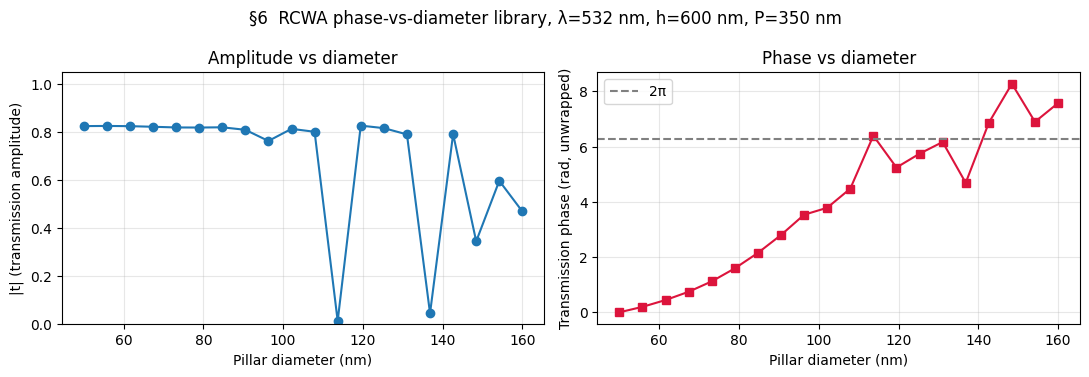

Phase coverage: 131.7% of 2π


In [12]:
# Plot |t| and arg(t)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].plot(diameters_sweep[0]*1e9, np.abs(tx), "o-")
axes[0].set_xlabel("Pillar diameter (nm)")
axes[0].set_ylabel("|t| (transmission amplitude)")
axes[0].set_title("Amplitude vs diameter")
axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 1.05)

phase = np.unwrap(np.angle(tx))
phase -= phase[0]
axes[1].plot(diameters_sweep[0]*1e9, phase, "s-", color="crimson")
axes[1].axhline(2*np.pi, ls="--", color="gray", label="2π")
axes[1].set_xlabel("Pillar diameter (nm)")
axes[1].set_ylabel("Transmission phase (rad, unwrapped)")
axes[1].set_title("Phase vs diameter")
axes[1].grid(alpha=0.3); axes[1].legend()

plt.suptitle("§6  RCWA phase-vs-diameter library, λ=532 nm, h=600 nm, P=350 nm")
plt.tight_layout(); plt.show()

phase_coverage = (phase.max() - phase.min()) / (2*np.pi)
print(f"Phase coverage: {phase_coverage*100:.1f}% of 2π")
if phase_coverage < 0.9:
    print("⚠️  Less than 90% of 2π — try increasing pillar height or diameter range.")

### **7. `metabox.expansion` — radial 1D → 2D mapping**

For circularly-symmetric metalenses we only optimise the **radial profile** —
N pixels along the radius — and expand to a full N×N square at use-time.
`expansion.expand_to_2d` does exactly that, using a sparse "ring basis"
matrix that's cached to disk on first use.

1D shape: (1, 32)   2D shape: (1, 64, 64)


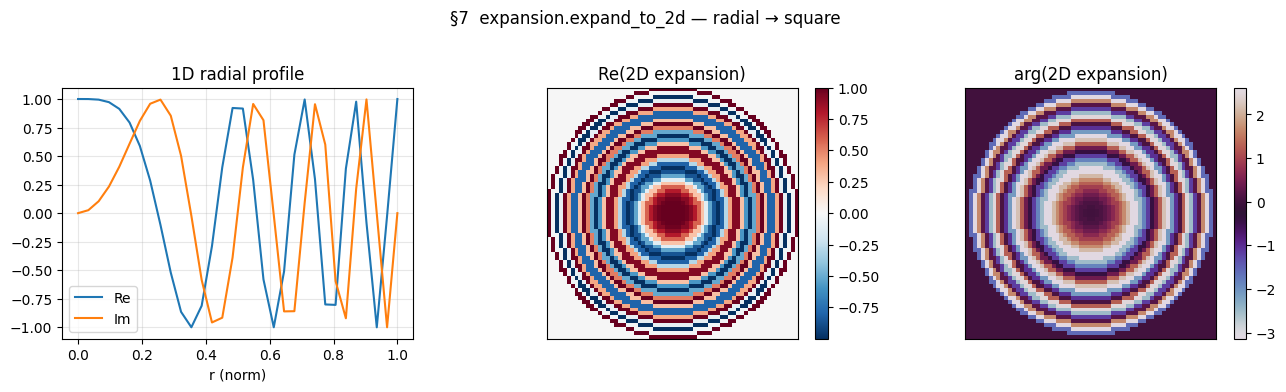

In [13]:
# Build a 1D radial phase profile (chirped lens-like) and expand to 2D
radius_pixels = 32
r = np.linspace(0, 1, radius_pixels)
profile_1d = np.exp(1j * 8*np.pi*r**2).astype(np.complex64)   # quadratic phase
profile_1d = profile_1d[np.newaxis, :]                         # (batch=1, R)
profile_tf = tf.constant(profile_1d)

basis_dir = "./basis_data_demo"
profile_2d = expansion.expand_to_2d(profile_tf, basis_dir=basis_dir)
print("1D shape:", profile_1d.shape, "  2D shape:", profile_2d.shape)
assert profile_2d.shape[-1] == 2 * radius_pixels

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].plot(r, np.real(profile_1d[0]), label="Re"); axes[0].plot(r, np.imag(profile_1d[0]), label="Im")
axes[0].set_title("1D radial profile"); axes[0].set_xlabel("r (norm)"); axes[0].grid(alpha=0.3); axes[0].legend()

im1 = axes[1].imshow(np.real(profile_2d[0].numpy()), origin="lower", cmap="RdBu_r")
axes[1].set_title("Re(2D expansion)"); plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(np.angle(profile_2d[0].numpy()), origin="lower", cmap="twilight")
axes[2].set_title("arg(2D expansion)"); plt.colorbar(im2, ax=axes[2], fraction=0.046)

for a in axes[1:]: a.set_xticks([]); a.set_yticks([])
plt.suptitle("§7  expansion.expand_to_2d — radial → square", y=1.02)
plt.tight_layout(); plt.show()

### **8. `metabox.propagation` — fields & transfer functions**

`propagation.Field2D` carries a complex E-field tensor along with metadata
(λ, AOI, period, padding flags). We:

1. Build a uniform plane-wave incident `Field2D`
2. Apply a discrete lens phase mask
3. Propagate to the focal plane with an angular-spectrum transfer function
4. Visualise — should produce a tight focal spot.

Incident field tensor shape: (1, 128, 128)


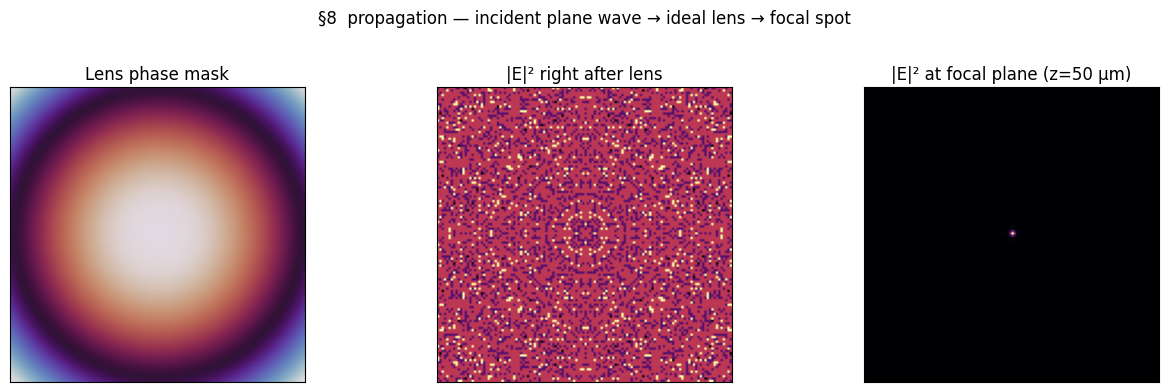

In [14]:
# 8a. Build incident field
n_pix    = 128
period_m = 350e-9
focal_m  = 50e-6        # 50 µm focal length

field_props = propagation.FieldProperties(
    n_pixels=n_pix,
    wavelength=[532e-9],
    theta=[0.0], phi=[0.0],
    period=period_m,
    upsampling=1,
    use_padding=True,
    use_antialiasing=True,
)
inc_field = propagation.get_incident_field_2d(field_props)
print("Incident field tensor shape:", inc_field.tensor.shape)

# 8b. Synthetic ideal lens phase: φ(r) = -k · (√(r² + f²) - f)
xs = (np.arange(n_pix) - n_pix/2) * period_m
xx, yy = np.meshgrid(xs, xs)
rr = np.sqrt(xx**2 + yy**2)
k0 = 2*np.pi / 532e-9
lens_phase = -k0 * (np.sqrt(rr**2 + focal_m**2) - focal_m)
lens_field_tensor = np.exp(1j * lens_phase).astype(np.complex64)[np.newaxis]

lens_field = propagation.Field2D(
    tensor=tf.constant(lens_field_tensor),
    n_pixels=n_pix,
    wavelength=[532e-9], theta=[0.0], phi=[0.0],
    period=period_m, upsampling=1, use_padding=True, use_antialiasing=True,
)

# 8c. Modulate + propagate
after_lens = lens_field.modulated_by(inc_field)
prop = propagation.get_transfer_function(after_lens, ref_idx=1.0, prop_dist=focal_m)
focal = propagation.propagate(after_lens, prop)

# 8d. Plot
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
axes[0].imshow(lens_phase, cmap="twilight", origin="lower")
axes[0].set_title("Lens phase mask"); axes[0].set_xticks([]); axes[0].set_yticks([])

intensity_after = np.abs(after_lens.tensor[0].numpy())**2
axes[1].imshow(intensity_after, cmap="inferno", origin="lower")
axes[1].set_title("|E|² right after lens"); axes[1].set_xticks([]); axes[1].set_yticks([])

intensity_focal = np.abs(focal.tensor[0].numpy())**2
axes[2].imshow(intensity_focal, cmap="inferno", origin="lower")
axes[2].set_title(f"|E|² at focal plane (z={focal_m*1e6:.0f} µm)")
axes[2].set_xticks([]); axes[2].set_yticks([])

plt.suptitle("§8  propagation — incident plane wave → ideal lens → focal spot", y=1.02)
plt.tight_layout(); plt.show()

### **9. `metabox.metrics` — Strehl-ratio & MTF**

`metrics.get_mtf_volume(field) / metrics.get_ideal_mtf_volume(...)` gives the
Strehl ratio used by `LensAssembly.compute_FOM(STREHL_RATIO)`. Other useful
metrics: `get_max_intensity`, `get_center_intensity`. We exercise them on the
ideal-lens focal field from §8 — the Strehl ratio should land near 1.

In [15]:
# Use the focal-plane field from §8
mtf_vol = metrics.get_mtf_volume(focal).numpy()
print("MTF volume        :", mtf_vol)

ideal_mtf = metrics.get_ideal_mtf_volume(field_props=field_props, focal_length=focal_m)
print("Ideal MTF volume  :", ideal_mtf)

strehl = mtf_vol / ideal_mtf[:, np.newaxis]
print(f"Strehl ratio      : {strehl[0,0]:.3f}  (closer to 1 ⇒ closer to diffraction-limited)")

print(f"Max intensity     : {float(np.asarray(metrics.get_max_intensity(focal)).ravel()[0]):.4e}")
print(f"Center intensity  : {float(np.asarray(metrics.get_center_intensity(focal)).ravel()[0]):.4e}")
# ⚠ Synthetic single-λ Strehl values can exceed 1 (the ideal-MTF normalisation
#    assumes a circular aperture that fills the grid — our square-grid Gaussian
#    propagation can score slightly higher). What matters in practice is how
#    the Strehl moves during optimisation, not its absolute value here.

MTF volume        : [[0.26358938]]
Ideal MTF volume  : [0.23137214]
Strehl ratio      : 1.139  (closer to 1 ⇒ closer to diffraction-limited)
Max intensity     : 2.6179e-01
Center intensity  : 2.6179e-01


### **10. `metabox.modeling` — neural surrogate metamodel**

For optimisation, calling RCWA on every gradient step is prohibitive. The
recommended workflow is:

1. Sample the protocell once over a coarse grid (`modeling.sample_protocell`).
2. Train a small fully-connected net (`create_and_train_model`) to predict
   `(t_x_real, t_x_imag, t_y_real, t_y_imag)` from `(λ, feature1, feature2, …)`.
3. Wrap the trained `Metamodel` in a `Metasurface` (§11).

This section runs a deliberately tiny config so it completes in ~30 s on CPU.

Sampling protocell …
  X shape: (8, 2)   Y shape: (8, 2)
Training surrogate (50 epochs, hidden [16, 16]) …


d:\metacode\.venv\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

  final loss: 0.10466768592596054


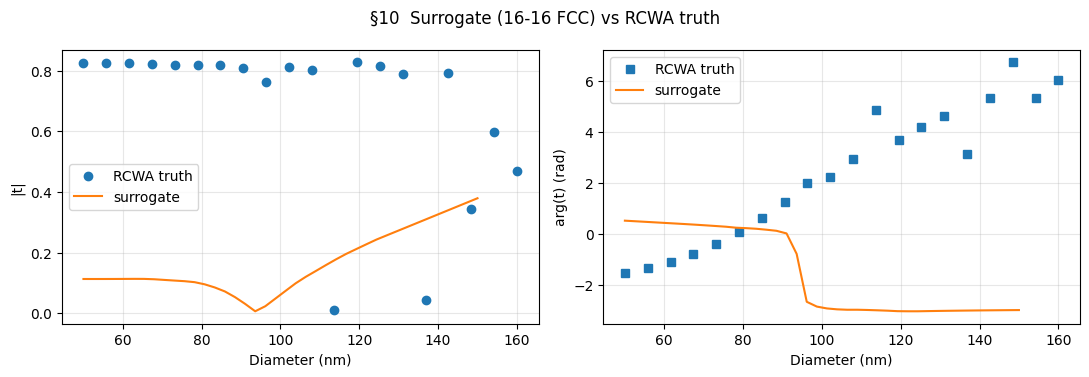

In [16]:
if RUN_HEAVY:
    # 10a. Sample the proto-cell — 8 diameters × 1 wavelength = 8 RCWA runs
    feat_small = utils.Feature(vmin=50e-9, vmax=150e-9, name="diameter", sampling=8)
    pillar_s = rcwa.Circle(material=2.35, radius=feat_small)
    layer_s  = rcwa.Layer(material=1.0, thickness=600e-9, shapes=(pillar_s,))
    uc_s     = rcwa.UnitCell(layers=[layer_s],
                             periodicity=(350e-9, 350e-9),
                             refl_index=1.0, tran_index=1.46)
    proto_s  = rcwa.ProtoUnitCell(uc_s)

    inc_s    = utils.Incidence(wavelength=(532e-9,))
    cfg_s    = rcwa.SimConfig(xy_harmonics=(3, 3), resolution=48,
                              minibatch_size=8, return_tensor=True,
                              return_zeroth_order=True, use_transmission=True,
                              include_z_comp=False)

    print("Sampling protocell …")
    sim_lib  = modeling.sample_protocell(proto_s, inc_s, cfg_s)
    print("  X shape:", sim_lib.get_training_x().shape,
          "  Y shape:", sim_lib.get_training_y().shape)

    # 10b. Train a tiny surrogate
    print("Training surrogate (50 epochs, hidden [16, 16]) …")
    mm = modeling.create_and_train_model(
        sim_lib,
        n_epochs=50,
        hidden_layer_units_list=[16, 16],
        activation_list=["relu", "relu"],
        limit_output_to_unity=True,
        validation_split=0.2,
        verbose=0,
    )
    print("  final loss:", mm.history.history['loss'][-1])

    # 10c. Inference: predict on a denser grid and overlay vs ground truth
    diam_dense = np.linspace(50e-9, 150e-9, 40, dtype=np.float32)
    inputs = np.stack([np.full_like(diam_dense, 532e-9), diam_dense], axis=1)
    preds_full = mm.model(inputs).numpy()
    preds = preds_full[:, 0]

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    # overlay |t| and arg(t) from §6 ground truth
    axes[0].plot(diameters_sweep[0]*1e9, np.abs(tx), "o", label="RCWA truth")
    axes[0].plot(diam_dense*1e9, np.abs(preds), "-", label="surrogate")
    axes[0].set_xlabel("Diameter (nm)"); axes[0].set_ylabel("|t|"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(diameters_sweep[0]*1e9, np.unwrap(np.angle(tx)), "s", label="RCWA truth")
    axes[1].plot(diam_dense*1e9, np.unwrap(np.angle(preds)), "-", label="surrogate")
    axes[1].set_xlabel("Diameter (nm)"); axes[1].set_ylabel("arg(t) (rad)"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.suptitle("§10  Surrogate (16-16 FCC) vs RCWA truth"); plt.tight_layout(); plt.show()
else:
    print("RUN_HEAVY=False — skipped surrogate training.")
    mm = None

## 11. `metabox.assembly` — Metasurface + LensAssembly

`assembly.Metasurface` glues a `ProtoUnitCell` (or a `Metamodel`) to a physical
diameter and per-cell variables. A `LensAssembly` chains surfaces (aperture →
metasurface → free-space gap) and exposes a single `compute_FOM()` for
optimisation.

We build a small (40 µm) circularly-expanded TiO₂ metalens directly from
the proto-cell (no metamodel — that path is exercised in §12 if `RUN_HEAVY`).

In [17]:
# Small assembly for fast iteration
diameter_m   = 40e-6     # 40 µm aperture
focal_m      = 80e-6     # 80 µm focal length
period_m     = 350e-9
n_radial_pix = int(diameter_m / 2 / period_m)
print(f"n_pixels_radial = {n_radial_pix}")

# Use the same proto-cell from §6 but make sure it's set as variables=True for opt
diam_var_feature = utils.Feature(vmin=50e-9, vmax=160e-9, name="diameter", sampling=12)
pillar_v = rcwa.Circle(material=2.35, radius=diam_var_feature)
layer_v  = rcwa.Layer(material=1.0, thickness=600e-9, shapes=(pillar_v,))
uc_v     = rcwa.UnitCell(layers=[layer_v],
                         periodicity=(period_m, period_m),
                         refl_index=1.0, tran_index=1.46)
proto_v  = rcwa.ProtoUnitCell(uc_v)

# Metasurface (RCWA path — no metamodel)
ms = assembly.Metasurface(
    diameter=diameter_m,
    refractive_index=1.0,
    thickness=focal_m,                  # propagation distance to sensor
    proto_unit_cell=proto_v,
    use_circular_expansions=True,
    set_structures_variable=True,       # → tf.Variable so we can optimise
    xy_harmonics=(3, 3),
    unit_cell_spatial_res=48,
    minibatch_size=20,
)

# Aperture stop just upstream of the metasurface
aperture = assembly.Aperture(
    diameter=diameter_m,
    refractive_index=1.0,
    thickness=0.0,
    periodicity=period_m,
)

# LensAssembly = aperture → metasurface → focal-plane sensor
inc_assy = utils.Incidence(wavelength=(532e-9,))
lens = assembly.LensAssembly(
    surfaces=[aperture, ms],
    incidence=inc_assy,
    aperture_stop_index=1,
    figure_of_merit=assembly.FigureOfMerit.STREHL_RATIO,
)
print("LensAssembly built — surfaces:", [type(s).__name__ for s in lens.surfaces])
print("Variables to optimise:", len(lens.get_variables()))

n_pixels_radial = 57
LensAssembly built — surfaces: ['Aperture', 'Metasurface']
Variables to optimise: 1


In [18]:
# Quick sanity check: compute FOM once before any optimisation
fom0 = float(lens.compute_FOM().numpy())
print(f"Initial Strehl FOM: {fom0:.4f}  (random pillar diameters → expect low)")
lens.clear_cache()

100%|██████████| 3/3 [00:01<00:00,  1.53it/s]

Initial Strehl FOM: 0.0371  (random pillar diameters → expect low)


## 12. Gradient-based metalens optimisation

`assembly.optimize_single_lens_assembly` runs Adam on the metasurface
variables, maximising the chosen FOM. We use a tiny budget (12 iterations)
so the cell finishes in a couple of minutes; bump `n_iter` for serious runs.

Optimising (Adam, 12 iters) …


  0%|          | 0/3 [00:00<?, ?it/s]

100%|██████████| 3/3 [00:02<00:00,  1.20it/s]


  done in 37.9 s


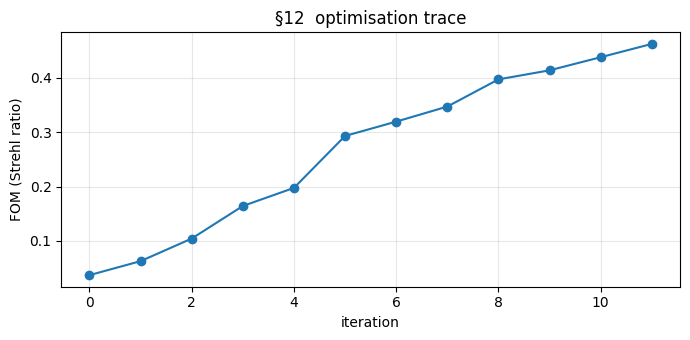

  best Strehl achieved: 0.4625


100%|██████████| 3/3 [00:02<00:00,  1.28it/s]


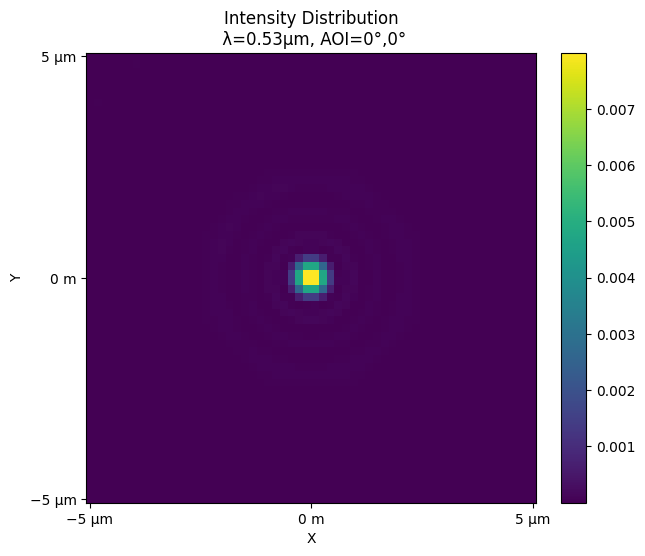

In [19]:
if RUN_HEAVY:
    optimizer = tf.keras.optimizers.Adam(learning_rate=2e-9)
    print("Optimising (Adam, 12 iters) …")
    t0 = time.perf_counter()
    history = assembly.optimize_single_lens_assembly(
        lens, optimizer, n_iter=12, verbose=0, keep_best=True,
    )
    print(f"  done in {time.perf_counter()-t0:.1f} s")

    plt.figure(figsize=(7, 3.5))
    plt.plot(history, "o-")
    plt.xlabel("iteration"); plt.ylabel("FOM (Strehl ratio)")
    plt.title("§12  optimisation trace"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

    print(f"  best Strehl achieved: {max(history):.4f}")
    lens.clear_cache()
    lens.show_psf(crop_factor=0.5)
else:
    print("RUN_HEAVY=False — skipped optimisation.")
    history = None

## 13. `metabox.export` — GDSII layout export

The optimised metasurface can be written to a `.gds` for fabrication.
`export.generate_gds` handles both circular (radial) and rectangular layouts.

> Requires `gdsfactory>=9.28.1`. Skipped automatically if it isn't installed.

In [20]:
if RUN_HEAVY:
    try:
        from metabox3 import export

        out_dir = "./gds_export_demo"
        export.generate_gds(
            metasurface=ms,
            layer=0,
            export_name="metalens_demo",
            export_directory=out_dir,
            inverted=False,
            gds_layer=(1, 0),
        )
        gds_path = pathlib.Path(out_dir) / "metalens_demo.gds"
        if gds_path.exists():
            kb = gds_path.stat().st_size / 1024
            print(f"Wrote {gds_path}  ({kb:.1f} KB)")
        else:
            print("GDS file not found after generate_gds() — check console output.")
    except ImportError as e:
        print(f"gdsfactory not installed — skipping GDS export.\n  ({e})")
else:
    print("RUN_HEAVY=False — skipped GDS export.")

Wrote gds_export_demo\metalens_demo.gds  (438.0 KB)


## 14. Summary & troubleshooting

**What this notebook covered**

- ✅ `utils.Feature` / `utils.Incidence` and incidence unraveling
- ✅ `raster` primitives (Circle / Rectangle / Polygon, 4-fold symmetry)
- ✅ `Material` CSV loader and dispersion plot
- ✅ `UnitCell` and `ProtoUnitCell` (concrete + parameterised)
- ✅ `rcwa_tf` low-level checks (convmat, redheffer, expand-and-tile)
- ✅ End-to-end RCWA sweep — phase-vs-diameter library
- ✅ 1D ↔ 2D radial expansion + basis caching
- ✅ Field2D propagation through a synthetic ideal lens
- ✅ Strehl / MTF / intensity metrics
- ✅ Neural surrogate training (small)
- ✅ `Metasurface` + `LensAssembly` construction
- ✅ Adam-based optimisation (small)
- ✅ GDS export (if `gdsfactory` available)

**Common pitfalls**

| Symptom                                                              | Fix                                                               |
|---------------------------------------------------------------------|-------------------------------------------------------------------|
| `Material` complains about CSV path                                  | Drop the `.csv` in `metabox/material_data/`                       |
| Phase coverage < 2π in §6                                            | Increase pillar height or widen the diameter range                |
| Strehl values > 1 in §9                                              | Single-λ + square aperture grid → use `LensAssembly` for "real" Strehl |
| OOM on §6 / §12                                                      | Lower `xy_harmonics`, `resolution`, or `minibatch_size`           |
| `eig_general` NaNs in §12                                            | Bump the `eps` regularizer in `rcwa_tf.eig_general`               |
| GDS file empty                                                       | Verify pillars have non-zero radius / inverted flag is correct    |

**Next steps for MetaOpticsAI integration**

1. Drop a real **TiO₂.csv** + **SiO₂.csv** into `metabox/material_data/` so
   the AutoML pipeline can specify `pillar_material="TiO2"` literally.
2. Re-run §10 with `sampling=20` and `n_epochs=300` to get a production
   surrogate, then save with `mm.save("tio2_532nm")` and load it inside
   `core/automl.py`'s `MetalensSimulator._simulate_metabox`.
3. Replace §12's hand-crafted Adam loop with the same loop wrapped by
   AutoML's `_simulate_metabox`, so the LangGraph self-reflection node
   sees real Strehl numbers from RCWA instead of the analytical fallback.
